In [51]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [52]:
df = pd.DataFrame({
    'soil_moisture': [0.10,0.15,0.20,0.40,0.60,0.35,0.18,0.45,0.05,0.80,0.27,0.55,0.70,0.12,0.30],
    'temperature_c': [34,30,26,22,28,30,19,22,35,24,33,33,21,25,20],
    'sunlight_hours': [9,8,7,4,8,10,12,5,9,11,2,6,1,9,7],
    'needs_water': [1,1,1,0,0,0,0,1,0,1,0,1,0,0,1]
})

In [53]:
df

,soil_moisture,temperature_c,sunlight_hours,needs_water
0,0.10,34,9,1
1,0.15,30,8,1
2,0.20,26,7,1
3,0.40,22,4,0
4,0.60,28,8,0
5,0.35,30,10,0
6,0.18,19,12,0
7,0.45,22,5,1
8,0.05,35,9,0
9,0.80,24,11,1


In [54]:
df.columns

Index(['soil_moisture', 'temperature_c', 'sunlight_hours', 'needs_water'], dtype='object')

In [55]:
X = df[['soil_moisture', 'temperature_c', 'sunlight_hours']]
y = df['needs_water']

In [56]:
X_min = X.min()
X_max = X.max()
X_scaled = (X - X_min)/(X_max - X_min + 1e-8)

In [57]:
X_scaled

,soil_moisture,temperature_c,sunlight_hours
0,0.066667,0.9375,0.727273
1,0.133333,0.6875,0.636364
2,0.200000,0.4375,0.545455
3,0.466667,0.1875,0.272727
4,0.733333,0.5625,0.636364
5,0.400000,0.6875,0.818182
6,0.173333,0.0000,1.000000
7,0.533333,0.1875,0.363636
8,0.000000,1.0000,0.727273
9,1.000000,0.3125,0.909091


In [58]:
X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=0.25, random_state=42,stratify=y)

In [59]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(8,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

In [60]:
model.compile(optimizer='sgd',loss = 'binary_crossentropy'
,metrics=['accuracy'])

# 🌱 Soil Moisture Prediction using Deep Learning

This project predicts whether a plant needs water based on:
- Soil moisture
- Temperature
- Sunlight hours

Model: Simple Neural Network (Keras)

In [61]:
history = model.fit(
    X_train.values,y_train.values,
    validation_data = (X_test.values,y_test.values),
    epochs = 100,batch_size=4,verbose = 1
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.5455 - loss: 0.7026 - val_accuracy: 0.5000 - val_loss: 0.6717
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5455 - loss: 0.7031 - val_accuracy: 0.5000 - val_loss: 0.6720
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5455 - loss: 0.7023 - val_accuracy: 0.5000 - val_loss: 0.6720
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5455 - loss: 0.7035 - val_accuracy: 0.5000 - val_loss: 0.6715
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5455 - loss: 0.7021 - val_accuracy: 0.5000 - val_loss: 0.6717
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5455 - loss: 0.7016 - val_accuracy: 0.5000 - val_loss: 0.6714
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5455 - loss: 0.7029 - val_accuracy: 0.5000 - val_loss: 0.6710
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5455 - loss: 0.7010 - val_accuracy: 0.5000 - val_loss

## Conclusion
- Model works on small dataset
- Deep learning is not ideal for small data
- Traditional ML models may perform better

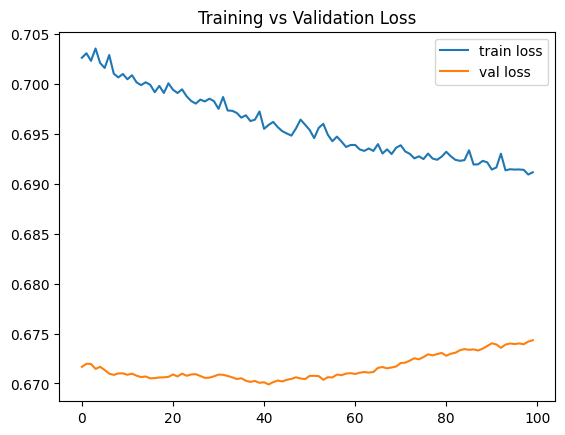

In [62]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()